# 10 — τ sensitivity of the soft ensembles (WP1)

**Goal.** Quantify how sensitive the deployed soft-median ensemble is to the percentile
threshold τ (production value **τ = 0.977**, `ensemble_final.pkl`).

**Method.** `src.sensitivity.cache_fold_scores()` re-fits the 4 detectors leakage-free per
walk-forward fold (`clone_unfit` + a fresh `FoldScaler` fit on fold-train only) and persists
raw train-normal (*ref*) and val scores under `outputs/cache/` (layout documented in the
module docstring). Every τ sweep afterwards is a pure numpy re-aggregation: percentile vs the
fold ref distribution → soft mean/median → threshold. Metrics are reported per fold and as the
**n_pos-weighted** aggregate (methodology contract: folds 1-2 carry 117/135 positives).
The sealed 2019-2021 test holdout is **not** evaluated here.

In [1]:
import os, sys, time
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.sensitivity import (cache_fold_scores, tau_curve, tau_stability, plot_tau_curve,
                             PRODUCTION_TAU, CACHE_DIR, FIGURES_DIR)
print('cache dir:', CACHE_DIR.relative_to(PROJECT_ROOT))

cache dir: outputs\cache


## Cache build / load
First call builds (~2 min, dominated by 5 AE fits); afterwards it is a disk load.

In [2]:
t0 = time.time()
fs = cache_fold_scores()   # cache hit -> load; rebuild=True to force the ~2 min refit
print(f'fold scores ready in {time.time()-t0:.1f}s')
for fid, d in fs.items():
    print(f"fold {fid}: {len(d['y_val'])} val rows, {int(d['y_val'].sum())} pos, "
          f"models={list(d['ref'])}")
import json
meta = json.load(open(CACHE_DIR / 'meta.json'))
print('build_seconds (last rebuild):', meta['build_seconds'])
print('dev-ref max abs drift vs committed ensemble meta:',
      {k: f'{v:.2e}' for k, v in meta['max_abs_diff_vs_ensemble_meta_refs'].items()})

fold scores ready in 0.0s
fold 1: 153 val rows, 53 pos, models=['mvg', 'svm', 'ae', 'if']
fold 2: 152 val rows, 64 pos, models=['mvg', 'svm', 'ae', 'if']
fold 3: 101 val rows, 2 pos, models=['mvg', 'svm', 'ae', 'if']
fold 4: 100 val rows, 10 pos, models=['mvg', 'svm', 'ae', 'if']
fold 5: 100 val rows, 6 pos, models=['mvg', 'svm', 'ae', 'if']
build_seconds (last rebuild): 112.7
dev-ref max abs drift vs committed ensemble meta: {'mvg': '0.00e+00', 'svm': '1.42e-14', 'ae': '1.46e-07', 'if': '1.11e-16'}


## τ sweep — [0.80, 1.00] step 0.0025, soft_median + soft_mean
Per fold: F1, F2, precision, recall, coverage (fraction of val weeks flagged).

In [3]:
t0 = time.time()
curve = tau_curve(fs)            # -> outputs/tables/tau_curve.csv
stab = tau_stability(curve)      # -> outputs/tables/tau_stability.csv
print(f'sweep + stability in {time.time()-t0:.1f}s (acceptance: ~5s)')
curve.head(3)

sweep + stability in 5.6s (acceptance: ~5s)


,mode,fold,tau,n_pos,F1,F2,precision,recall,coverage
0,soft_median,1,0.8000,53,0.574586,0.764706,0.40625,0.981132,0.836601
1,soft_median,1,0.8025,53,0.574586,0.764706,0.40625,0.981132,0.836601
2,soft_median,1,0.8050,53,0.574586,0.764706,0.40625,0.981132,0.836601


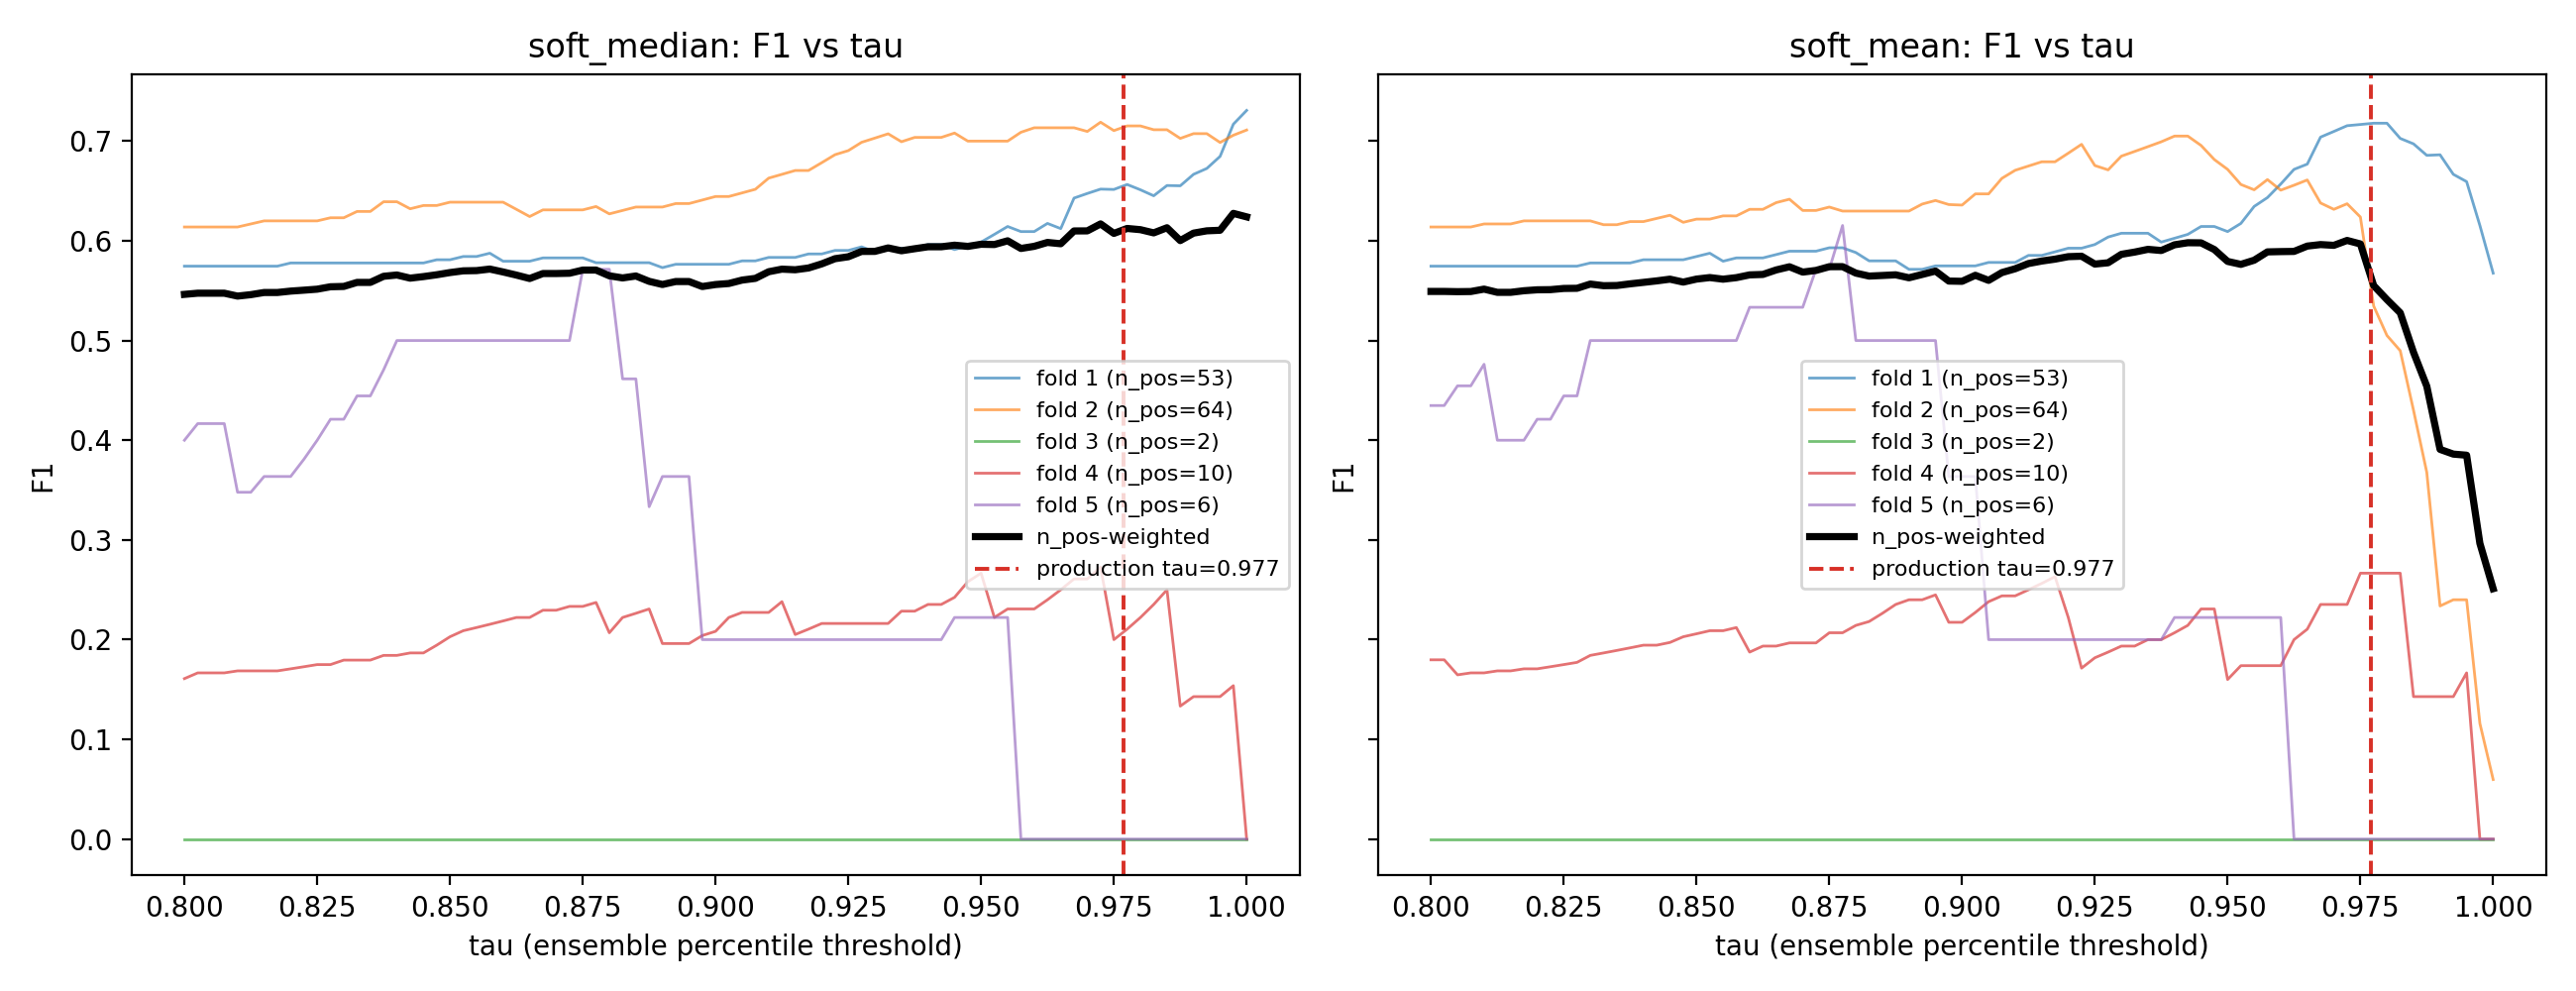

In [4]:
fig_path = plot_tau_curve(curve)   # -> outputs/figures/tau_curve.png (dpi=200)
from IPython.display import Image
Image(filename=str(fig_path), width=980)

## τ* stability across folds

In [5]:
per_fold = stab[stab['fold'] != 'summary'].pivot_table(
    index='fold', columns=['mode', 'metric'], values='tau_star')
print('per-fold argmax tau*:')
display(per_fold.round(4))
summary = stab[stab['fold'] == 'summary'][
    ['mode', 'metric', 'tau_min', 'tau_max', 'tau_std', 'tau_star']].rename(
    columns={'tau_star': 'tau_wmedian'})
print('summary (tau_wmedian = n_pos-weighted median of per-fold tau*):')
display(summary.round(4))
print(f'production tau = {PRODUCTION_TAU}')

per-fold argmax tau*:


mode   soft_mean         soft_median        
metric        F1      F2          F1      F2
fold                                        
1         0.9800  0.9725      1.0000  0.8575
2         0.9425  0.8675      0.9725  0.9325
3         1.0000  1.0000      1.0000  1.0000
4         0.9825  0.8950      0.9725  0.8775
5         0.8775  0.8775      0.8800  0.8800

summary (tau_wmedian = n_pos-weighted median of per-fold tau*):


,mode,metric,tau_min,tau_max,tau_std,tau_wmedian
5,soft_median,F1,0.8800,1.0,0.0442,0.9725
11,soft_median,F2,0.8575,1.0,0.0516,0.8800
17,soft_mean,F1,0.8775,1.0,0.0437,0.9425
23,soft_mean,F2,0.8675,1.0,0.0535,0.8775


production tau = 0.9769


In [6]:
w = curve[(curve['mode'] == 'soft_median') & (curve['fold'] == 'weighted')]
near = w[(w.tau >= 0.94)][['tau', 'F1', 'F2', 'precision', 'recall', 'coverage']]
f1_max = w['F1'].max()
f1_at_prod = float(w.loc[(w.tau - PRODUCTION_TAU).abs().idxmin(), 'F1'])
print(f'weighted F1: max over grid = {f1_max:.3f}, at production tau = {f1_at_prod:.3f} '
      f'(gap {f1_max - f1_at_prod:.3f})')
near.round(3).tail(18)

weighted F1: max over grid = 0.628, at production tau = 0.612 (gap 0.015)


,tau,F1,F2,precision,recall,coverage
468,0.958,0.592,0.690,0.481,0.778,0.558
469,0.960,0.594,0.691,0.484,0.778,0.555
470,0.962,0.598,0.694,0.488,0.778,0.549
471,0.965,0.597,0.690,0.489,0.770,0.543
472,0.968,0.610,0.697,0.506,0.770,0.524
473,0.970,0.610,0.693,0.509,0.763,0.516
474,0.972,0.617,0.693,0.522,0.756,0.498
475,0.975,0.607,0.677,0.519,0.733,0.486
476,0.978,0.612,0.679,0.527,0.733,0.480
477,0.980,0.611,0.675,0.530,0.726,0.474


### Interpretation (≤5 lines)
The production τ=0.977 sits on a **plateau, not a cliff**: weighted F1 stays within ~0.03 of its
grid maximum across the whole τ∈[0.94, 1.00] band, and the n_pos-weighted median of the per-fold
argmax-F1 τ* (0.9725) lands one grid step from the deployed value. The instability is **across
folds**, not across τ: τ*(F1) ranges 0.88→1.00 (std ≈ 0.044) because folds 3-5 have 2-10 positives.
F2 tells the real trade-off: a recall-oriented operator would cut τ to ≈0.88 (weighted F2 0.70 vs
0.68), paying with coverage ≈60% of val weeks flagged vs ≈48% at the production setting.